# ROC curve and AUC score

In [25]:
#import libraries
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np

In [26]:
#Genearte 2 class datasets
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

In [27]:
#split the dataset into train and test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

In [28]:
#Create a NO skill Dummy model
dummy_model_prob=[0 for _ in range(len(y_test))]
dummy_model_prob

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [29]:
#ctreate a basic Logistic regeression model
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [30]:
#prediction based on probability
model_prob = model.predict_proba(x_test)
model_prob

array([[9.58428073e-01, 4.15719266e-02],
       [3.83831626e-01, 6.16168374e-01],
       [4.11273164e-01, 5.88726836e-01],
       [1.44173511e-01, 8.55826489e-01],
       [2.12947713e-01, 7.87052287e-01],
       [5.55480847e-01, 4.44519153e-01],
       [5.14731162e-02, 9.48526884e-01],
       [7.07458405e-01, 2.92541595e-01],
       [9.60382480e-01, 3.96175198e-02],
       [9.74865222e-01, 2.51347784e-02],
       [7.00084361e-02, 9.29991564e-01],
       [5.36592357e-01, 4.63407643e-01],
       [1.57430062e-01, 8.42569938e-01],
       [9.72214496e-01, 2.77855037e-02],
       [2.38226153e-01, 7.61773847e-01],
       [6.06972700e-01, 3.93027300e-01],
       [6.77454819e-01, 3.22545181e-01],
       [9.94083969e-01, 5.91603133e-03],
       [6.63801693e-01, 3.36198307e-01],
       [9.89328499e-01, 1.06715013e-02],
       [9.83815250e-01, 1.61847501e-02],
       [4.72590409e-02, 9.52740959e-01],
       [8.61759436e-01, 1.38240564e-01],
       [1.78752451e-02, 9.82124755e-01],
       [2.051878

In [31]:
#lets focus on the positive values
model_prob = model_prob[:,1]
model_prob

array([4.15719266e-02, 6.16168374e-01, 5.88726836e-01, 8.55826489e-01,
       7.87052287e-01, 4.44519153e-01, 9.48526884e-01, 2.92541595e-01,
       3.96175198e-02, 2.51347784e-02, 9.29991564e-01, 4.63407643e-01,
       8.42569938e-01, 2.77855037e-02, 7.61773847e-01, 3.93027300e-01,
       3.22545181e-01, 5.91603133e-03, 3.36198307e-01, 1.06715013e-02,
       1.61847501e-02, 9.52740959e-01, 1.38240564e-01, 9.82124755e-01,
       9.79481211e-01, 9.16738987e-01, 4.91966477e-01, 5.46488487e-02,
       7.75772263e-03, 9.85789708e-01, 9.60914675e-01, 9.24310389e-01,
       1.25286754e-02, 9.35371574e-01, 3.11355253e-01, 3.81567128e-01,
       2.75584251e-02, 9.10878879e-01, 7.30599337e-02, 8.54209011e-01,
       3.87905173e-01, 9.39328813e-01, 6.12093791e-01, 6.42263960e-01,
       4.40920712e-01, 9.43010623e-03, 7.11270641e-03, 7.92255896e-01,
       3.30460596e-03, 8.49534701e-01, 7.91629668e-01, 9.19255631e-01,
       9.61149794e-01, 9.43852273e-01, 2.83628348e-01, 5.83152748e-02,
      

In [32]:
#let's calculate the AUC score
dummy_model_auc = roc_auc_score(y_test, dummy_model_prob)   # Auc score for dummy model
model_auc = roc_auc_score(y_test, model_prob)      # Auc score for logistic model
print(dummy_model_auc)
print(model_auc)

0.5
0.9105862775217615


In [40]:
#calculate the ROC curve
dummy_model_fpr, dummy_model_tpr, thresholds_dummy = roc_curve(y_test, dummy_model_prob)
model_fpr, model_tpr, thresholds_model = roc_curve(y_test, model_prob)

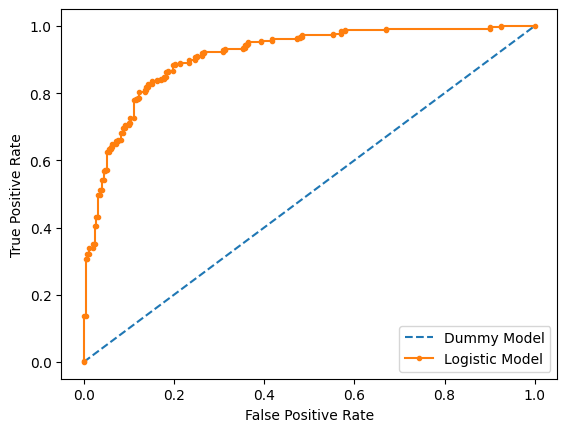

In [41]:
#plot the Roc curve
pyplot.plot(dummy_model_fpr, dummy_model_tpr, linestyle='--', label='Dummy Model')
pyplot.plot(model_fpr, model_tpr, marker='.', label='Logistic Model')
#axis label
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
#show the legend
pyplot.legend()
#show the plot
pyplot.show()